In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Step 2: Load Dataset
df = pd.read_csv('telco_customer_churn.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Step 3: Basic Dataset Info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Step 4: Data Cleaning
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Data Cleaning Done!")
print("Dataset Shape after cleaning:", df.shape)

✅ Data Cleaning Done!
Dataset Shape after cleaning: (7032, 21)


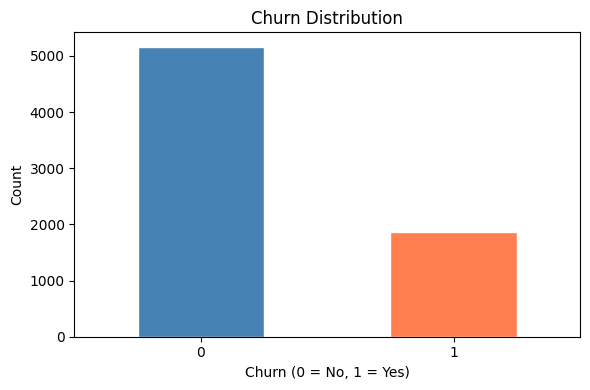

✅ Churn Distribution plot saved!


In [5]:
# Step 5: Churn Distribution
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

print("✅ Churn Distribution plot saved!")

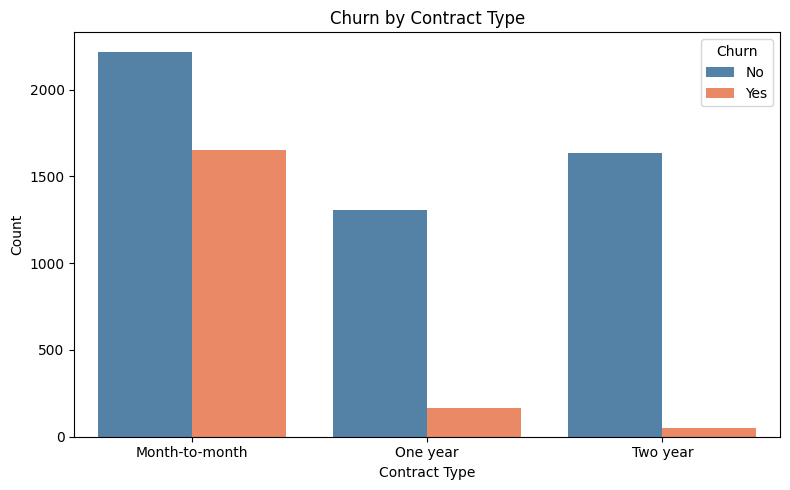

✅ Churn by Contract Type plot saved!


In [6]:
# Step 6: Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue', 'coral'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

print("✅ Churn by Contract Type plot saved!")

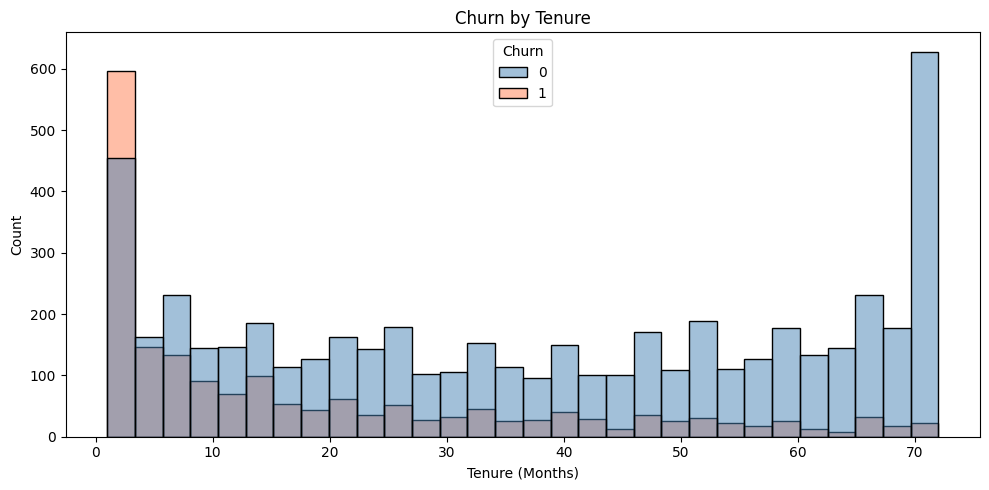

✅ Churn by Tenure plot saved!


In [7]:
# Step 7: Churn by Tenure
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue', 'coral'])
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

print("✅ Churn by Tenure plot saved!")

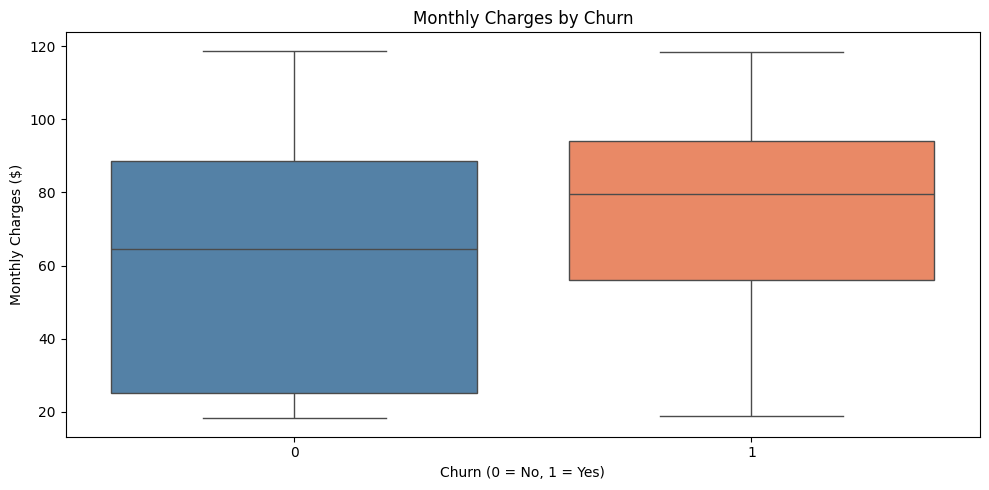

✅ Monthly Charges plot saved!


In [8]:
# Step 8: Churn by Monthly Charges
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue', 'coral'])
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('churn_by_monthly_charges.png', dpi=150)
plt.show()

print("✅ Monthly Charges plot saved!")

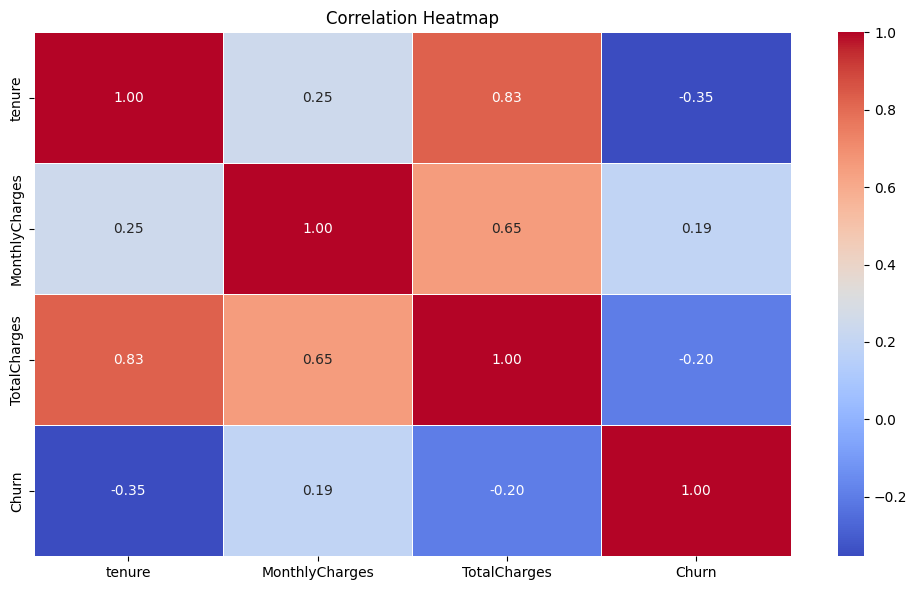

✅ Correlation Heatmap saved!


In [9]:
# Step 9: Correlation Heatmap
plt.figure(figsize=(10, 6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("✅ Correlation Heatmap saved!")

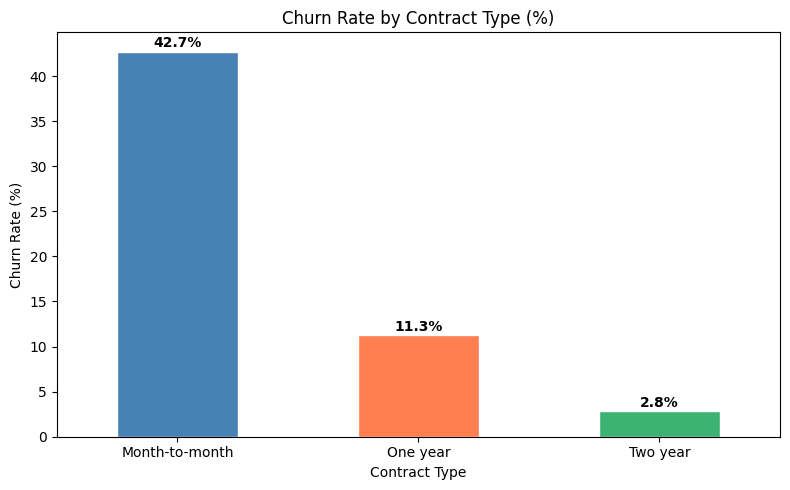

✅ Churn Rate by Contract plot saved!


In [10]:
# Step 10: Churn Rate by Contract Type
churn_rate = df.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
churn_rate.plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_rate_by_contract.png', dpi=150)
plt.show()

print("✅ Churn Rate by Contract plot saved!")

In [12]:
# Step 11: Key Insights
print("=" * 55)
print("         KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 55)

total_customers = len(df)
churned = df['Churn'].sum()
churn_rate = (churned / total_customers) * 100

print(f"\n📌 Total Customers: {total_customers}")
print(f"📌 Churned Customers: {churned}")
print(f"📌 Overall Churn Rate: {churn_rate:.1f}%")

monthly_churn = df[df['Contract'] == 'Month-to-month']['Churn'].mean() * 100
print(f"\n📌 Monthly Contract Churn Rate: {monthly_churn:.1f}%")

low_tenure_churn = df[df['tenure'] < 3]['Churn'].mean() * 100
print(f"📌 Churn Rate for tenure < 3 months: {low_tenure_churn:.1f}%")

print("\n📌 Recommendations:")
print("   → Focus retention on monthly contract customers")
print("   → Offer discounts to new customers in first 3 months")
print("   → Promote long-term contracts with incentives")

print("\n✅ Customer Churn Analysis Complete!")

         KEY INSIGHTS & RECOMMENDATIONS

📌 Total Customers: 7032
📌 Churned Customers: 1869
📌 Overall Churn Rate: 26.6%

📌 Monthly Contract Churn Rate: 42.7%
📌 Churn Rate for tenure < 3 months: 59.1%

📌 Recommendations:
   → Focus retention on monthly contract customers
   → Offer discounts to new customers in first 3 months
   → Promote long-term contracts with incentives

✅ Customer Churn Analysis Complete!
